Import library

In [1]:
import requests
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression #Library untuk Regresi Linier
from sklearn.metrics import mean_squared_error #Library MSE
from sklearn.ensemble import IsolationForest #Library untuk mencari data Outlier

In [4]:
#membaca file

data = pd.read_csv("Gold Futures Historical Data.csv", sep=";") #Sesuaikan dengan directory file masing-masing

In [5]:
#3.	Menampilkan n data
data.head(4)

,Date,Price,Open,High,Low,Volume,Volatility,Fluktuasi
0,2021,"1,818.55","1,781.25","1,820.45","1,758.90",222.61K,"1,9",Naik
1,2021,"1,783.90","1,757.20","1,815.50","1,745.40",3.92M,"1,5",Naik
2,2021,"1,757.00","1,816.70","1,836.90","1,721.10",3.65M,"-3,4",Turun
3,2021,"1,818.10","1,817.00","1,835.90","1,677.90",3.66M,"0,3",Netral


In [6]:
#4.	Menampilkan deskripsi data sebelum Pre-Processing
data.describe()

,Date
count,179.000000
mean,2013.960894
std,4.312724
min,2007.000000
25%,2010.000000
50%,2014.000000
75%,2018.000000
max,2021.000000


In [7]:
#5.	Melihat tipe data kolom sebelum dilakukan Pre-Processing
data.dtypes

Date           int64
Price         object
Open          object
High          object
Low           object
Volume        object
Volatility    object
Fluktuasi     object
dtype: object

In [8]:
#6.	Mengubah tipe data kolom yang diperlukan
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Volatility'] = data['Volatility'].str.replace(',', '.').astype(float)

Setelah pre processing

In [9]:
#7.	Melihat tipe data kolom setelah dilakukan Pre-Processing
data.dtypes

Date            int64
Price         float64
Open          float64
High          float64
Low           float64
Volume         object
Volatility    float64
Fluktuasi      object
dtype: object

In [10]:
#8.	Menampilkan deskripsi data setelah dilakukan Pre-Processing
data.describe()

,Date,Price,Open,High,Low,Volatility
count,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,2013.960894,1331.139385,1327.106983,1366.603631,1290.482123,0.715642
std,4.312724,315.711490,318.376190,325.603855,308.757162,5.076547
min,2007.000000,648.100000,640.400000,655.500000,607.000000,-18.000000
25%,2010.000000,1181.400000,1181.400000,1209.650000,1160.300000,-2.550000
50%,2014.000000,1334.300000,1333.100000,1350.200000,1309.000000,0.400000
75%,2018.000000,1562.850000,1554.400000,1579.500000,1511.100000,3.700000
max,2021.000000,2017.100000,2026.900000,2120.000000,1913.000000,13.900000


Pengolahan data

In [11]:
#9.	Mengelompokkan data rata-rata harga berdasarkan tahun
avg_gold_price = data.groupby('Date')['Price'].mean() #Mencari rata-rata harga untuk dikelompokkan berdasarkan tahun

In [12]:
print('Rata-rata harga emas per tahun\n',avg_gold_price)

Rata-rata harga emas per tahun
 Date
2007     705.483333
2008     876.775000
2009     984.783333
2010    1237.783333
2011    1574.075000
2012    1676.325000
2013    1394.400000
2014    1263.933333
2015    1234.533333
2016    1305.200000
2017    1345.766667
2018    1352.216667
2019    1453.883333
2020    1805.750000
2021    1794.822727
Name: Price, dtype: float64


In [13]:
#10.	Memisahkan data menjadi varibel X dan Y untuk visualisasi data
x=avg_gold_price.index
y=avg_gold_price.values

Text(0, 0.5, 'Rata-Rata Harga Emas')

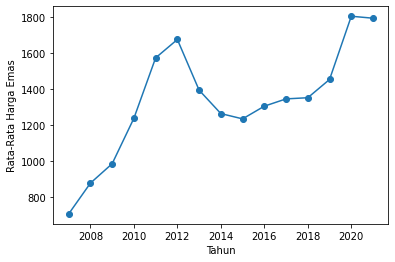

In [14]:
plt.scatter(x, y)
plt.plot(x, y)
plt.xlabel('Tahun')
plt.ylabel('Rata-Rata Harga Emas')

Regresi Linier Sederhana

In [15]:
#11.	Mencari rata-rata harga Emas tahun 2022 menggunakan Regresi Linier
linreg=LinearRegression()
x=np.array(x).reshape(-1,1) #Data tahun dimasukkan kedalam ordo matrix n*1
linreg.fit(x, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [16]:
Gold_2022=np.array(2022).reshape(-1,1) #Membuat data tahun baru yaitu tahun 2022
pred_ipm=linreg.predict(Gold_2022)

In [17]:
print('\nPrediksi rata-rata Harga Emas tahun 2022 =\n', pred_ipm.item())


Prediksi rata-rata Harga Emas tahun 2022 =
 1745.584473304465


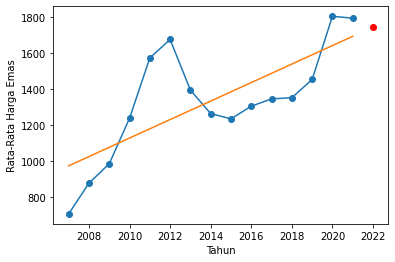

In [18]:
#12.	Membuat visualisasi hasil dari Regresi Linier
plt.scatter(x, y)
plt.plot(x, y)
plt.xlabel('Tahun')
plt.ylabel('Rata-Rata Harga Emas')
plt.scatter(Gold_2022, pred_ipm, c='red')
pred_y=linreg.predict(x)
plt.plot(x, pred_y)
plt.show()

In [19]:
#13.	Rangkuman dari hasil Regresi Linier menggunakan indikator MSE
MSE=mean_squared_error(y,pred_y)
print('MSE = ', MSE)

MSE =  42465.96491878395


Data Outlier

In [20]:
#14.	Mengambil 2 kolom dari dataset
dataIso = data[['Date','Volatility']] #Mengambil 2 kolom dari data yang diolah untuk mencari outlier dari volatility

In [21]:
#15.	Menentukan tingkat toleransi data outlier
clf = IsolationForest(contamination=0.2) #Contamination adalah seberapa besar tingkat toleransi data yang menyimpang
pred = clf.fit_predict(dataIso)

In [22]:
#16.	Memasukkan data outlier kedalam data frame
dataIso['Outlier']=pred.reshape(-1,1) #Data outlier dimasukkan kedalam ordo matrix n*1

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [23]:
#17.	Mencetak hasil data outlier
print(dataIso)

     Date  Volatility  Outlier
0    2021         1.9        1
1    2021         1.5        1
2    2021        -3.4       -1
3    2021         0.3        1
4    2021         2.3        1
..    ...         ...      ...
174  2007        -2.9       -1
175  2007         2.6        1
176  2007        -1.0        1
177  2007         2.7        1
178  2007         2.6        1

[179 rows x 3 columns]


In [24]:
#18.	Melihat data yang termasuk outlier
dataOutlier = dataIso['Volatility'].loc[dataIso['Outlier']==-1]
print('Data yang termasuk outlier:\n', dataOutlier.value_counts())

Data yang termasuk outlier:
  6.7     2
 13.6    2
 8.3     2
-18.0    1
-2.9     1
 12.3    1
-2.0     1
 10.5    1
-7.3     1
-12.1    1
-11.4    1
-4.2     1
 7.0     1
 10.0    1
 6.5     1
-6.5     1
 11.0    1
 6.1     1
 0.9     1
 10.4    1
 6.6     1
-7.2     1
 9.9     1
-9.3     1
-3.4     1
 7.7     1
-7.7     1
 13.9    1
-5.8     1
-10.3    1
 9.6     1
 3.1     1
-7.0     1
Name: Volatility, dtype: int64


In [25]:
#19.	Melihat data yang tidak termasuk outlier
dataNoOutlier = dataIso['Volatility'].loc[dataIso['Outlier']==1]
print('Data yang tidak termasuk outlier:\n', dataNoOutlier.value_counts())

Data yang tidak termasuk outlier:
  0.4    5
 2.6    5
 3.7    4
-2.7    3
-5.4    3
       ..
 1.4    1
 2.3    1
-2.9    1
 5.9    1
-3.3    1
Name: Volatility, Length: 89, dtype: int64


Text(0.5, 1.0, 'Outlier Volatility Emas')

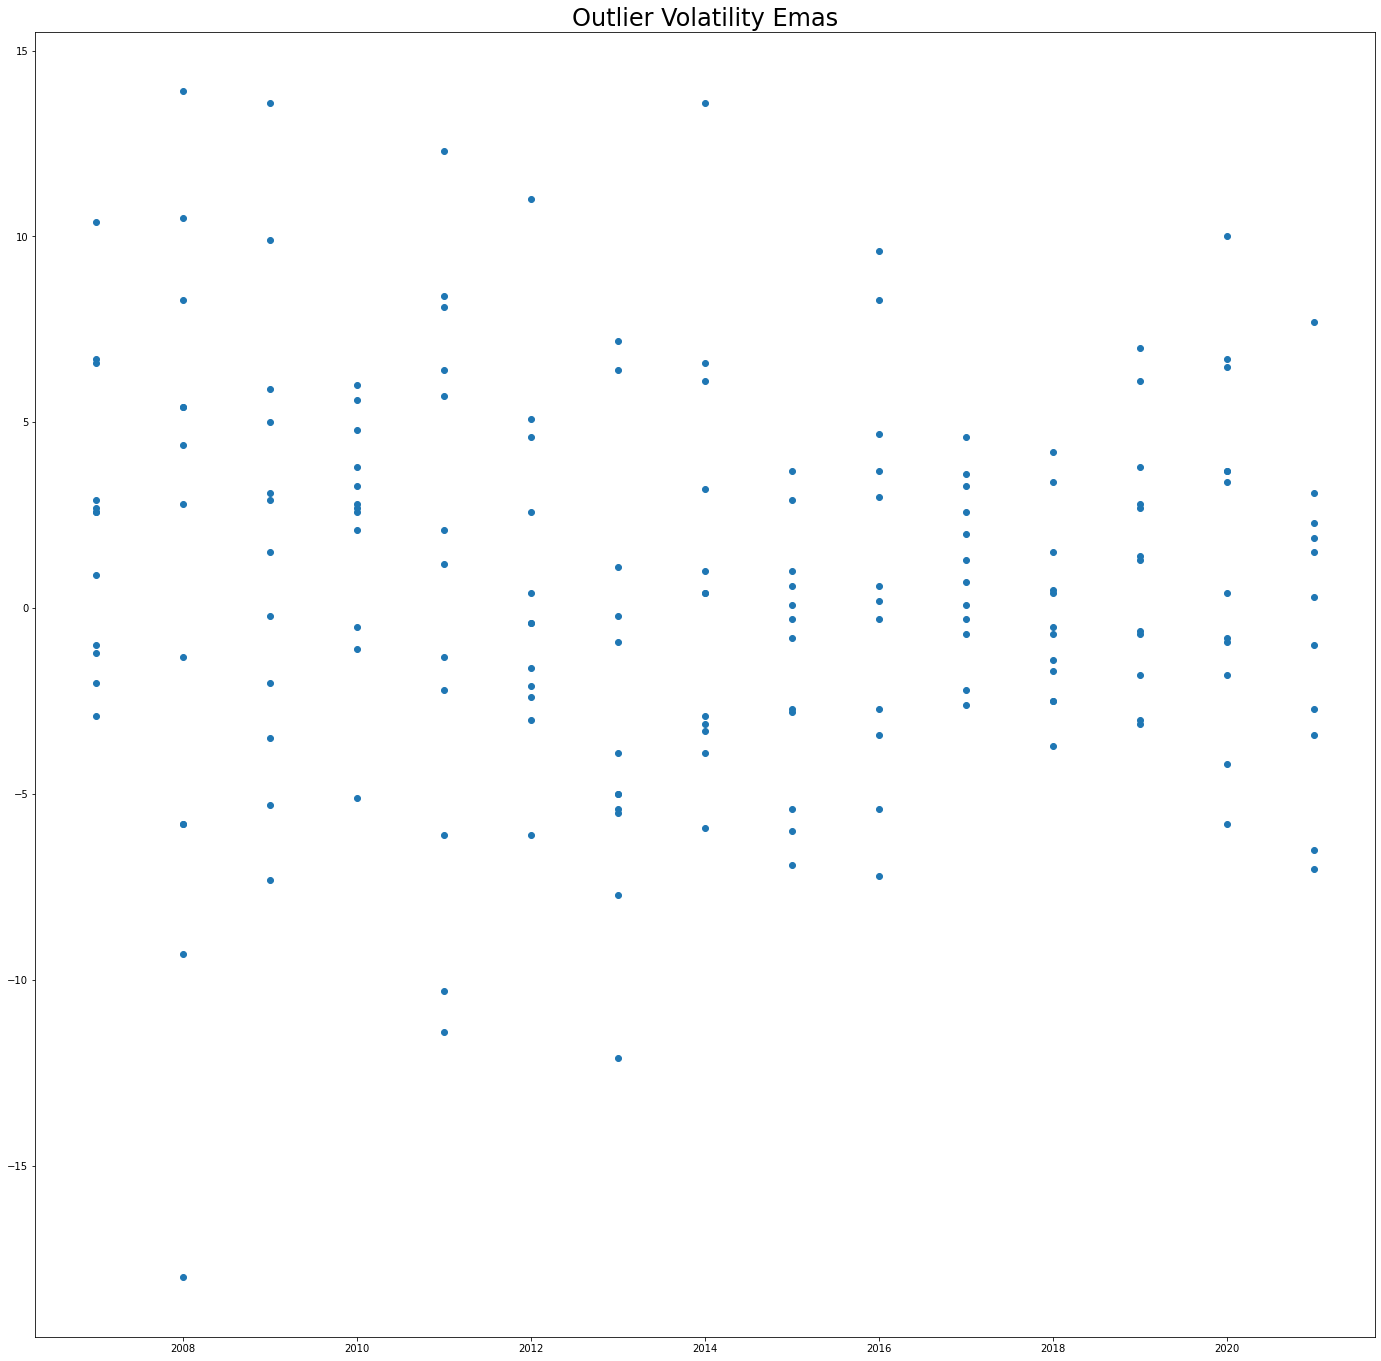

In [26]:
#20.	Memvisualisasikan data outlier
plt.figure(figsize=(24,24))
plt.scatter(dataIso['Date'],dataIso['Volatility'])
plt.title('Outlier Volatility Emas', fontsize=24)

Pengolahan Data Harga Open

In [27]:
avg_gold_open = data.groupby('Date')['Open'].mean() #Mencari rata-rata harga untuk dikelompokkan berdasarkan tahun

In [28]:
print('Rata-rata harga emas per tahun\n',avg_gold_open)

Rata-rata harga emas per tahun
 Date
2007     689.991667
2008     876.450000
2009     967.075000
2010    1211.483333
2011    1561.541667
2012    1666.991667
2013    1436.150000
2014    1267.600000
2015    1246.225000
2016    1314.650000
2017    1326.466667
2018    1357.791667
2019    1433.691667
2020    1784.783333
2021    1805.586364
Name: Open, dtype: float64


In [29]:
x=avg_gold_open.index
y=avg_gold_open.values

Text(0, 0.5, 'Rata-Rata Harga Emas')

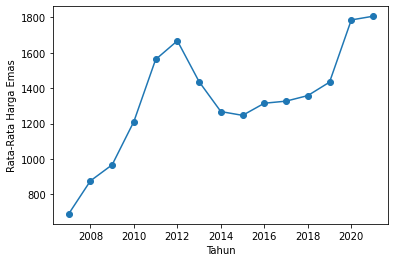

In [30]:
plt.scatter(x, y)
plt.plot(x, y)
plt.xlabel('Tahun')
plt.ylabel('Rata-Rata Harga Emas')

Regresi Linier Sederhana

In [31]:
linreg=LinearRegression()
x=np.array(x).reshape(-1,1) #Data tahun dimasukkan kedalam ordo matrix n*1
linreg.fit(x, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [32]:
Gold_2022=np.array(2022).reshape(-1,1) #Membuat data tahun baru yaitu tahun 2022
pred_ipm=linreg.predict(Gold_2022)

In [33]:
print('\nPrediksi rata-rata Harga Emas tahun 2022 =\n', pred_ipm.item())


Prediksi rata-rata Harga Emas tahun 2022 =
 1746.26937950938


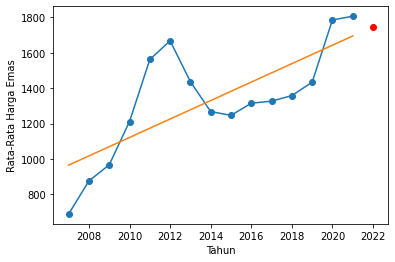

In [34]:
plt.scatter(x, y)
plt.plot(x, y)
plt.xlabel('Tahun')
plt.ylabel('Rata-Rata Harga Emas')
plt.scatter(Gold_2022, pred_ipm, c='red')
pred_y=linreg.predict(x)
plt.plot(x, pred_y)
plt.show()

In [35]:
MSE=mean_squared_error(y,pred_y)
print('MSE = ', MSE)

MSE =  42417.29032839342
